In [1]:

import glob
import re
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.stats import mannwhitneyu, spearmanr

from defect_detection.data.features import extract_features
from defect_detection.utils import find_project_root
from defect_detection.data.manifest import load_config

PROJECT_ROOT = find_project_root()
config = load_config()

CWRU_DIR = PROJECT_ROOT / config["paths"]["cwru_dir"]
FS = config["cwru"]["sampling_rate_hz"]
WINDOW_SIZE = config["window_size"]
N_WINDOWS_PER_FILE = 5

sns.set_theme(style="whitegrid")

#### Inspect .mat file keys across a few files

In [19]:

sample_paths = sorted(glob.glob(str(CWRU_DIR / "*.mat")))[:5]
 
for path in sample_paths:
    mat = loadmat(path)
    de_keys = [k for k in mat.keys() if "DE_time" in k]
    print(f"{Path(path).name}: DE keys = {de_keys}")

B007_0.mat: DE keys = ['X118_DE_time']
B007_1.mat: DE keys = ['X119_DE_time']
B007_2.mat: DE keys = ['X121_DE_time']
B007_3.mat: DE keys = ['X120_DE_time']
B014_0.mat: DE keys = ['X185_DE_time']


#### Build a file inventory and extract features

In [ ]:

def parse_filename(path: Path):
    name = path.stem

    if name.startswith("Normal"):
        idx = int(name.split("_")[1])
        return {"condition": "normal", "fault_type": None, "severity": None, "sample_idx": idx}

    match = re.match(r"(B|IR|OR)(\d{3})(\d)?_(\d)", name)
    if not match:
        raise ValueError(f"Unrecognized filename pattern: {name}")

    fault_code, diameter_code, position_code, idx = match.groups()
    fault_map = {"B": "ball", "IR": "inner_race", "OR": "outer_race"}
    severity_map = {"007": 0.007, "014": 0.014, "021": 0.021}

    return {
        "condition": "fault",
        "fault_type": fault_map[fault_code],
        "severity": severity_map[diameter_code],
        "position": position_code,  
        "sample_idx": int(idx),
    }


def load_de_signal(path: Path) -> np.ndarray:
    mat = loadmat(path)
    de_key = [k for k in mat.keys() if "DE_time" in k][0]
    return mat[de_key].flatten()


def get_nonoverlapping_windows(signal: np.ndarray, window_size: int, n_windows: int) -> list[np.ndarray]:
    """Pick n_windows evenly spaced, non-overlapping windows from a signal."""
    max_start = len(signal) - window_size
    if max_start <= 0:
        raise ValueError("Signal too short for one window")

    # Evenly spaced start points across the usable range, guaranteed non-overlapping
    starts = np.linspace(0, max_start, n_windows, dtype=int)
    # Enforce non-overlap explicitly (guards against very short signals / large n_windows)
    starts = np.array(sorted(set(starts)))
    valid_starts = [starts[0]]
    for s in starts[1:]:
        if s - valid_starts[-1] >= window_size:
            valid_starts.append(s)

    return [signal[s:s + window_size] for s in valid_starts[:n_windows]]

all_paths = sorted(CWRU_DIR.glob("*.mat"))
print(f"Total .mat files found: {len(all_paths)}")

records = []
for path in all_paths:
    meta = parse_filename(path)
    signal = load_de_signal(path)
    windows = get_nonoverlapping_windows(signal, WINDOW_SIZE, N_WINDOWS_PER_FILE)

    for w_idx, window in enumerate(windows):
        feats = extract_features(window, fs=FS)
        records.append({
            "file": path.name,
            "window_idx": w_idx,
            "condition": meta["condition"],
            "fault_type": meta["fault_type"],
            "severity": meta["severity"],
            "RMS": feats[0],
            "Peak": feats[1],
            "Crest Factor": feats[2],
            "Spectral Kurtosis": feats[3],
            "TKEO": feats[4],
        })

df = pd.DataFrame(records)
FEATURE_COLS = ["RMS", "Peak", "Crest Factor", "Spectral Kurtosis", "TKEO"]

print(df["condition"].value_counts())
print(f"\nNormal windows: {(df.condition == 'normal').sum()} "
      f"(expected {4 * N_WINDOWS_PER_FILE})")
print(f"Fault windows: {(df.condition == 'fault').sum()} "
      f"(expected {36 * N_WINDOWS_PER_FILE})")

Total .mat files found: 40
condition
fault     180
normal     20
Name: count, dtype: int64

Normal windows: 20 (expected 20)
Fault windows: 180 (expected 180)


#### Feature correlation heatmap

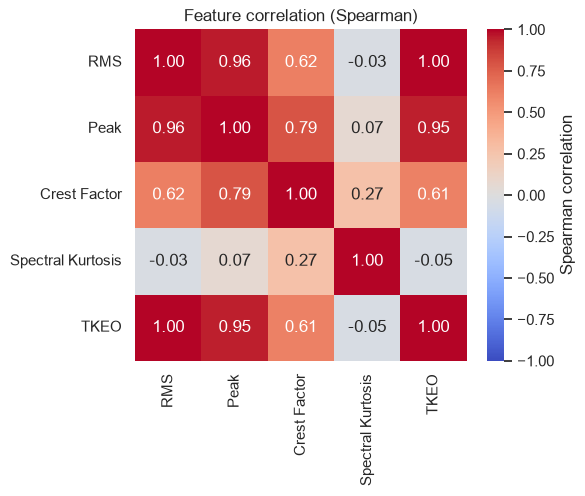

In [ ]:

corr = df[FEATURE_COLS].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Spearman correlation"})
plt.title("Feature correlation (Spearman)")
plt.tight_layout()
plt.show()

### Feature correlation observations
RMS, Peak, and TKEO show very high pairwise Spearman correlation ($ρ ≥ 0.95$), indicating substantial redundancy among these three time-domain magnitude-based features. In particular, RMS and TKEO are almost perfectly correlated ($ρ = 1.00$) in this dataset. Crest Factor shows moderate correlation with the energy-based features ($ρ = 0.61–0.79$), consistent with its definition as their ratio. Spectral Kurtosis is nearly uncorrelated with all other features ($|ρ| ≤ 0.27$), confirming it captures distinct, complementary information in the frequency domain rather than duplicating the time-domain energy features. This redundancy structure is worth keeping in mind when interpreting SHAP feature importances later, since correlated features can split attributed importance in the model.


#### Normal vs. fault Mann-Whitney U test per feature

* Two-sided: no strong directional prediction (RMS/Peak could plausibly go either way,
or show no meaningful difference) 
* One-sided: fault physically expected to exceed normal, per the underlying
signal-processing theory (impulsiveness / non-Gaussian bursts / burst energy)

In [ ]:

TWO_SIDED_FEATURES = {"RMS", "Peak"}
ONE_SIDED_FEATURES = {"Crest Factor", "Spectral Kurtosis", "TKEO"}

results = []
for feat in FEATURE_COLS:
    normal_vals = df.loc[df.condition == "normal", feat].values
    fault_vals = df.loc[df.condition == "fault", feat].values

    if feat in TWO_SIDED_FEATURES:
        alternative = "two-sided"
        hypothesis_desc = "fault != normal"
    else:
        alternative = "greater"
        hypothesis_desc = "fault > normal"

    stat, p = mannwhitneyu(fault_vals, normal_vals, alternative=alternative)

    alpha = 0.05
    conclusion = (
        f"reject H0: {hypothesis_desc} (significant)" if p < alpha
        else f"fail to reject H0: no significant evidence for {hypothesis_desc}"
    )

    results.append({
        "feature": feat,
        "test_type": alternative,
        "n_normal": len(normal_vals),
        "n_fault": len(fault_vals),
        "U_statistic": stat,
        "p_value": p,
        "conclusion": conclusion,
    })

mwu_results_df = pd.DataFrame(results)
print(mwu_results_df.to_string(index=False))

          feature test_type  n_normal  n_fault  U_statistic      p_value                                                    conclusion
              RMS two-sided        20      180       3600.0 2.333618e-13                      reject H0: fault != normal (significant)
             Peak two-sided        20      180       3600.0 2.333618e-13                      reject H0: fault != normal (significant)
     Crest Factor   greater        20      180       3384.0 5.647305e-11                       reject H0: fault > normal (significant)
Spectral Kurtosis   greater        20      180       1250.0 9.875133e-01 fail to reject H0: no significant evidence for fault > normal
             TKEO   greater        20      180       3600.0 1.166809e-13                       reject H0: fault > normal (significant)


#### Violin plots-normal vs. fault, per feature (with p-value annotated)

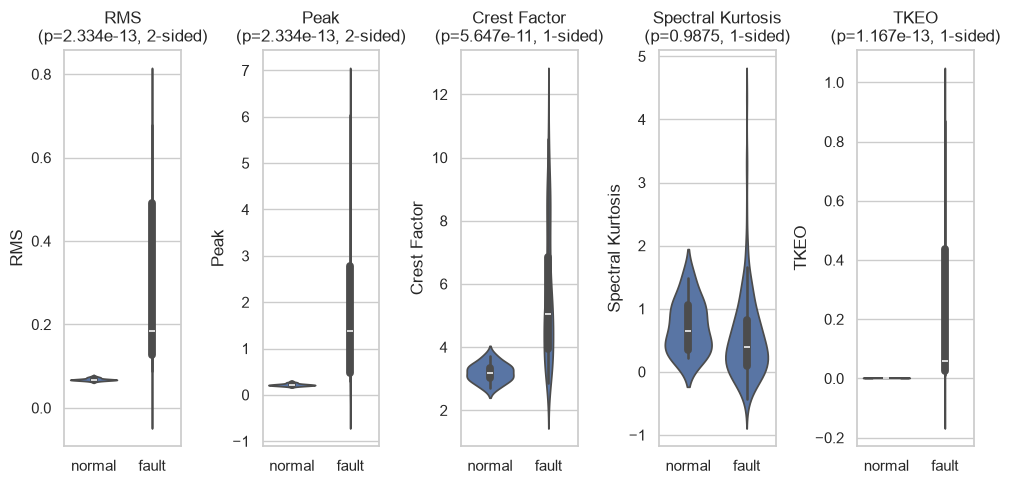

In [ ]:

fig, axes = plt.subplots(1, 5, figsize=(10, 5))

for ax, feat in zip(axes, FEATURE_COLS):
    sns.violinplot(data=df, x="condition", y=feat, ax=ax, order=["normal", "fault"])
    row = mwu_results_df.loc[mwu_results_df.feature == feat].iloc[0]
    tag = "2-sided" if row.test_type == "two-sided" else "1-sided"
    ax.set_title(f"{feat}\n(p={row.p_value:.4g}, {tag})")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

##### Two-sided re-test for Spectral Kurtosis
The one-sided "greater" test for Spectral Kurtosis failed to reject H0, but the violin plot
suggests fault might actually be *lower* than normal, the opposite direction from the original
hypothesis. A one-sided "greater" test cannot detect an effect in the opposite direction by
construction, so we explicitly check "less" here to see if that's what's happening.

In [ ]:
 
feat = "Spectral Kurtosis"
normal_vals = df.loc[df.condition == "normal", feat].values
fault_vals = df.loc[df.condition == "fault", feat].values
 
stat_less, p_less = mannwhitneyu(fault_vals, normal_vals, alternative="less")
stat_two, p_two = mannwhitneyu(fault_vals, normal_vals, alternative="two-sided")
 
print(f"Spectral Kurtosis, fault < normal (one-sided 'less'): U={stat_less}, p={p_less:.4g}")
print(f"Spectral Kurtosis, fault != normal (two-sided):        U={stat_two}, p={p_two:.4g}")
 
if p_less < 0.05:
    print("\n-> Significant evidence that fault < normal (reversed direction from original hypothesis).")
elif p_two < 0.05:
    print("\n-> Significant difference detected (two-sided), but direction unclear from 'less' test alone.")
else:
    print("\n-> No significant evidence of a difference in either direction.")

Spectral Kurtosis, fault < normal (one-sided 'less'): U=1250.0, p=0.01262
Spectral Kurtosis, fault != normal (two-sided):        U=1250.0, p=0.02524

-> Significant evidence that fault < normal (reversed direction from original hypothesis).


### Normal vs. fault — Mann-Whitney U test results

- **RMS, Peak, and TKEO** all show extremely strong, clean separation between normal and fault
  windows ($p ≈ 1e-13, U = 3600$ i.e. every fault window ranked above every normal window).
  This matches the visual separation seen in the violin plots and confirms these three
  magnitude-based features are strongly discriminative.
- **Crest Factor** is also significantly higher for fault windows ($p = 5.6e-11$), consistent
  with the original hypothesis that impulsive fault signatures raise the peak-to-RMS ratio.
- **Spectral Kurtosis produced the key surprise of this analysis.** The initial one-sided test
  (fault > normal) failed to reject H0 ($p = 0.99$), and the violin plot suggested the opposite
  pattern. A follow-up one-sided test in the reverse direction confirmed this: Spectral Kurtosis
  is significantly lower for fault windows than normal windows ($p = 0.013$), the opposite of
  what the harmonics/non-Gaussian-burst theory predicted. This effect is real but noticeably
  weaker and noisier than the other four features (U = 1250 vs. U = 3600 for RMS/Peak/TKEO,
  indicating substantial overlap between the two distributions rather than clean separation).

**On the reliability of these results:** with only 4 independent normal recordings and 36
independent fault recordings, windows drawn from the same file are not truly independent
observations, so the very small p-values for RMS/Peak/Crest Factor/TKEO likely overstate the
precision of the evidence. The direction and presence of an effect for these four features is
well supported by both the tests and the visualizations, but the exact p-values should not be
over-interpreted. The Spectral Kurtosis result is less affected by this concern, since
pseudo-replication tends to inflate false positives rather than produce false negatives, so
the reversed-direction finding is reasonably trustworthy despite the small sample size.

**Implications for later analysis:**
- RMS, Peak, Crest Factor, and TKEO are strong candidates for driving the binary defect-gate
  decision, given their large and consistent separation between conditions.
- The Spectral Kurtosis reversal is an open question worth revisiting. Possible explanations include the `nperseg=256` window not resolving
  fault-frequency bands well at this sampling rate, the fault severities in this dataset being
  too mild to produce the expected harmonic bursts, or averaging kurtosis across all frequency
  bins diluting a localized effect concentrated in specific bands.
- Given the redundancy identified in the correlation heatmap (RMS/Peak/TKEO near-collinear),
  Crest Factor and Spectral Kurtosis are likely to carry the most *independent* discriminative
  signal, even though Spectral Kurtosis's effect is weaker and in an unexpected direction.

#### Box plots by severity, colored by fault type

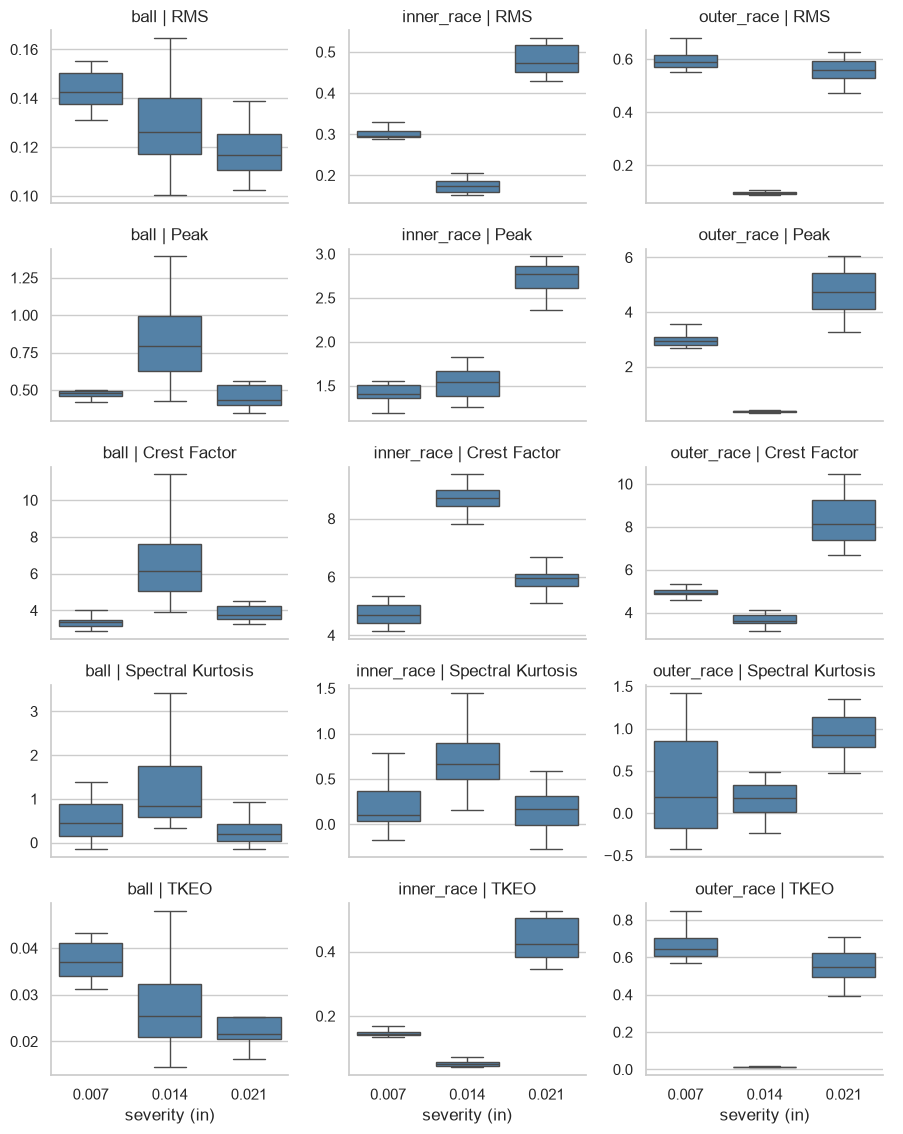

In [ ]:
fault_df = df[df.condition == "fault"].copy()

melted = fault_df.melt(
    id_vars=["fault_type", "severity"],
    value_vars=FEATURE_COLS,
    var_name="feature", value_name="value"
)
 
fault_type_order = ["ball", "inner_race", "outer_race"]
 
g = sns.catplot(
    data=melted, x="severity", y="value",
    row="feature", col="fault_type",
    col_order=fault_type_order,
    row_order=FEATURE_COLS,
    kind="box", sharey=False, showfliers=False,
    height=2.3, aspect=1.3,
    color="steelblue",
)
g.set_titles("{col_name} | {row_name}")
g.set_axis_labels("severity (in)", "")
plt.tight_layout()
plt.show()

#### Severity monotonicity-Spearman correlation, pooled across fault types

In [ ]:

severity_results = []
rho, p = spearmanr(fault_df["severity"], fault_df[FEATURE_COLS].values, axis=0)

if isinstance(rho, np.ndarray):
    severity_rhos = rho[0, 1:]
    severity_ps = p[0, 1:]
else:
    severity_rhos, severity_ps = [rho], [p]

for feat, r, pv in zip(FEATURE_COLS, severity_rhos, severity_ps):
    conclusion = (
        f"significant monotonic trend (rho={r:.3f})" if pv < 0.05
        else f"no significant monotonic trend (rho={r:.3f})"
    )
    severity_results.append({"feature": feat, "spearman_rho": r, "p_value": pv, "conclusion": conclusion})

severity_results_df = pd.DataFrame(severity_results)
print(severity_results_df.to_string(index=False))

          feature  spearman_rho      p_value                                  conclusion
              RMS     -0.012833 8.642405e-01 no significant monotonic trend (rho=-0.013)
             Peak      0.168137 2.406037e-02     significant monotonic trend (rho=0.168)
     Crest Factor      0.366785 4.099715e-07     significant monotonic trend (rho=0.367)
Spectral Kurtosis      0.092449 2.170767e-01  no significant monotonic trend (rho=0.092)
             TKEO     -0.021606 7.734279e-01 no significant monotonic trend (rho=-0.022)


### Severity monotonicity-pooled Spearman test vs. faceted box plots

**Pooled test results:** only Peak ($ρ = 0.17, p = 0.024$) and Crest Factor ($ρ = 0.37,
p < 0.0001$) show a significant pooled monotonic trend with severity. RMS, Spectral Kurtosis,
and TKEO show no significant pooled trend.

**Box plots (faceted by fault type) tell a more complete, and partly contradictory, story.**
Within every individual fault type (ball, inner race, outer race), none of the 5 features show
a clean, consistent monotonic increase across the three severities (0.007" → 0.014" → 0.021").
Most features instead show a **non-monotonic, peaked-in-the-middle or dip-then-rise pattern**
that differs in shape from one fault type to another. This is most striking for **Crest
Factor**, which produced the strongest pooled significant result, yet within each individual
fault type it clearly peaks at moderate severity (0.014") and is *not* monotonically increasing,the opposite pattern the pooled correlation seems to suggest.

**Why the pooled test and the box plots disagree:** pooling across fault types before testing
conflates two different effects, genuine within-type severity trends, and simple baseline
offset differences between fault types (e.g. inner race sitting at a systematically different
feature level than ball, independent of severity). Because fault type is an unmodeled grouping
variable in the pooled test, it can produce an apparent "trend" driven by which fault type
happens to dominate at a given severity level in the dataset, rather than a real monotonic
relationship. The faceted box plots, which examine each fault type independently, are the more
trustworthy view here, and they indicate that **severity does not have a simple monotonic
effect on these features** in this dataset.

**Reliability:** with only 4 independent files per fault-type/severity combination, this
analysis has limited power to resolve the true shape of the severity relationship, and the
pooled test's very small p-value for Crest Factor benefits from the same window-level
pseudo-replication concern noted earlier. The presence of a real, detectable fault (per the
earlier normal-vs-fault results) is well supported. The specific shape of how severity affects
these features is not well resolved by this dataset and should be treated as exploratory.

**Does this match expectations?** Only partially. The original hypothesis (features increasing
steadily with severity) is not supported. Instead, several features show non-monotonic
behavior that differs by fault type, which is a plausible outcome for early-to-moderate stage
faults (0.007"–0.021") and is consistent with some literature on bearing fault progression, but
was not the simple pattern originally assumed.

**Implications for the project:**
- The fault-**type** discriminability found earlier (normal vs. fault, and general
  separation between ball/inner_race/outer_race) is well supported and can be relied on with
  reasonable confidence.
- The fault-**severity** dimension is a much weaker, more exploratory assumption.